# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [80]:
import pandas as pd
import os

data_dir = "../../05_src/data/fires/"
file_path = os.path.join(data_dir, "forestfires.csv")

# Load data
# Loadeed data using relative path as specified in assignment instructions. 
# I did not use environment variable (.env) method which was shown in 04_transforms notebook for locating data file

df_raw = pd.read_csv(file_path)


In [81]:
# Inspect dataframe
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [82]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [83]:
# Get X and Y
X = fires_dt.drop(columns='area')
y = fires_dt['area']


In [84]:
# inspect
X.shape, y.shape

((517, 12), (517,))

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [85]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [86]:
# noted earlier that we have both numeric and categorical variables. So, we'll separate them below.

num_cols = [
    'coord_x', 'coord_y', 'ffmc', 'dmc', 'dc',
    'isi', 'temp', 'rh', 'wind', 'rain'
]

cat_cols = ['month', 'day']


In [87]:
# Numeric pipeline: scaling only
num_pipe_1 = Pipeline([
    ('scaler', StandardScaler())
])

# Categorical pipeline: one-hot encoding
cat_pipe = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Column transformer
preproc1 = ColumnTransformer([
    ('num', num_pipe_1, num_cols),
    ('cat', cat_pipe, cat_cols)
])


### Preproc 2

Create preproc2 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [88]:
from sklearn.preprocessing import StandardScaler, PowerTransformer


# Numeric pipeline: scaling + non-linear transformation
num_pipe_2 = Pipeline([
    ('scaler', StandardScaler()),
    ('transform', PowerTransformer(method='yeo-johnson'))
])

# Column transformer
preproc2 = ColumnTransformer([
    ('num', num_pipe_2, num_cols),
    ('cat', cat_pipe, cat_cols)
])



## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [94]:
# for baseline regressor, we select Ridge which is linear and fast, It works well with scaled features
# for advanced regressor, we select RandomForestFire, It is non-linear, handles interactions and compatible to SHAP.

from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

In [95]:
# Pipeline A = preproc1 + baseline

pipe_A = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', Ridge())
])


In [96]:
# Pipeline B = preproc2 + baseline

pipe_B = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', Ridge())
])


In [97]:
# Pipeline C = preproc1 + advanced model

pipe_C = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', RandomForestRegressor(random_state=42))
])


In [98]:
# Pipeline D = preproc2 + advanced model

pipe_D = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', RandomForestRegressor(random_state=42))
])

    

In [101]:
# view/print pipeplines to see how they look

pipe_A

,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [102]:
pipe_B

,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [103]:
pipe_C

,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [104]:
pipe_D

,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [105]:
# first to select what we are optimizing (for prediction problem, not a corrolation metrics). RMSE and MAE are good. RMSE is best choice

scoring = 'neg_root_mean_squared_error'


In [106]:
# decide what params to tune.  Stanard choices can be regrarros_aplha for basline model and e_estimator or max-depth for adcavnce model
# Baseline (Ridge)

param_grid_baseline = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

# Advanced (Random Forest)
param_grid_advanced = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [None, 10]
}


In [107]:
# Test-Train Split
from sklearn.model_selection import train_test_split

X = fires_dt.drop(columns='area')
y = fires_dt['area']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [108]:
# Grid Search
from sklearn.model_selection import GridSearchCV

# Grid search for pipeline A
grid_A = GridSearchCV(
    estimator=pipe_A,
    param_grid=param_grid_baseline,
    scoring=scoring,
    cv=5
)

grid_A.fit(X_train, y_train)


,estimator,"Pipeline(step...r', Ridge())])"
,param_grid,"{'regressor__alpha': [0.01, 0.1, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [109]:
grid_A.best_params_

{'regressor__alpha': 100.0}

In [110]:

# Grid search for pipeline B
grid_B = GridSearchCV(
    estimator=pipe_B,
    param_grid=param_grid_baseline,
    scoring=scoring,
    cv=5,
    n_jobs=-1
)

grid_B.fit(X_train, y_train)


,estimator,"Pipeline(step...r', Ridge())])"
,param_grid,"{'regressor__alpha': [0.01, 0.1, ...]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [111]:
# Grid search for pipeline C

grid_C = GridSearchCV(
    estimator=pipe_C,
    param_grid=param_grid_advanced,
    scoring=scoring,
    cv=5,
    n_jobs=-1
)

grid_C.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'regressor__max_depth': [None, 10], 'regressor__n_estimators': [100, 200]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [112]:
# Grid search for pipeline D

grid_D = GridSearchCV(
    estimator=pipe_D,
    param_grid=param_grid_advanced,
    scoring=scoring,
    cv=5,
    n_jobs=-1
)

grid_D.fit(X_train, y_train)


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'regressor__max_depth': [None, 10], 'regressor__n_estimators': [100, 200]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


# Observation: Gridsearch of Pipleline B took aroudn 30 seconds - much longer than other models. It's expected as that Pipelines involving non-linear transformations (Yeo–Johnson) required significantly longer tuning time due to repeated parameter estimation during cross-validation.”

# Evaluate

+ Which model has the best performance?

The best-performing model was selected based on cross-validated RMSE.

In [113]:
# Compare Gridsearches of all 4 piplelines

results = pd.DataFrame({
    'pipeline': ['A', 'B', 'C', 'D'],
    'best_rmse': [
        -grid_A.best_score_,
        -grid_B.best_score_,
        -grid_C.best_score_,
        -grid_D.best_score_,
    ],
    'best_params': [
        grid_A.best_params_,
        grid_B.best_params_,
        grid_C.best_params_,
        grid_D.best_params_,
    ]
})

results.sort_values('best_rmse')


,pipeline,best_rmse,best_params
1,B,38.918311,{'regressor__alpha': 100.0}
0,A,39.425319,{'regressor__alpha': 100.0}
3,D,47.398933,"{'regressor__max_depth': None, 'regressor__n_e..."
2,C,48.187528,"{'regressor__max_depth': None, 'regressor__n_e..."


In [114]:
print("Best performing pipeline:")
print(results.sort_values('best_rmse').iloc[0])

Best performing pipeline:
pipeline                                 B
best_rmse                        38.918311
best_params    {'regressor__alpha': 100.0}
Name: 1, dtype: object


In [115]:
best_row = results.sort_values('best_rmse').iloc[0]

best_pipeline_label = best_row['pipeline']

best_grid = {
    'A': grid_A,
    'B': grid_B,
    'C': grid_C,
    'D': grid_D
}[best_pipeline_label]

print(f"Selected model: Pipeline {best_pipeline_label}")
print(f"Cross-validated RMSE: {-best_grid.best_score_:.3f}")


Selected model: Pipeline B
Cross-validated RMSE: 38.918


# Export

+ Save the best performing model to a pickle file.

The best-performing pipeline was serialized and saved as a pickle file to ensure reproducibility and facilitate reuse in future analyses

In [116]:
best_model = best_grid.best_estimator_


In [117]:
import pickle

with open('best_forest_fire_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)


In [118]:
# Check the export (shows the saved model, if not broken through final steps)
with open('best_forest_fire_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

loaded_model



,steps,"[('preprocessing', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [120]:
# the best-perfroming model was pipeline B, in which we had used Ridge regressor. S, for SHAP we use .Linear Explainer method (not tree)

import shap
import numpy as np

# Extract preprocessing and model steps
preprocessor = best_model.named_steps['preprocessing']
model = best_model.named_steps['regressor']

# Transform the test data
X_test_transformed = preprocessor.transform(X_test)

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Create SHAP explainer for linear model
explainer = shap.explainers.Linear(
    model,
    X_test_transformed,
    feature_names=feature_names
)

# Compute SHAP values
shap_values = explainer(X_test_transformed)




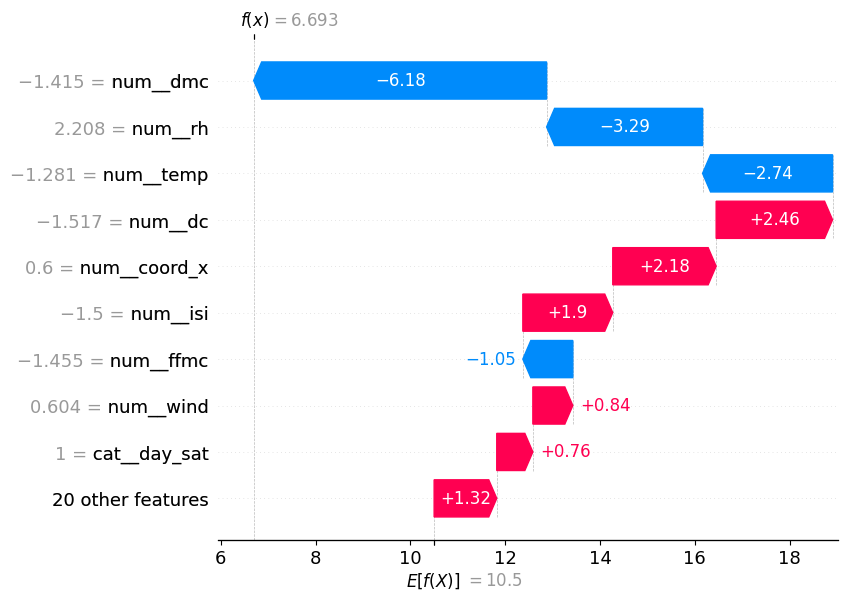

In [121]:
# select one observation from the test set

idx = 0

shap.plots.waterfall(shap_values[idx])

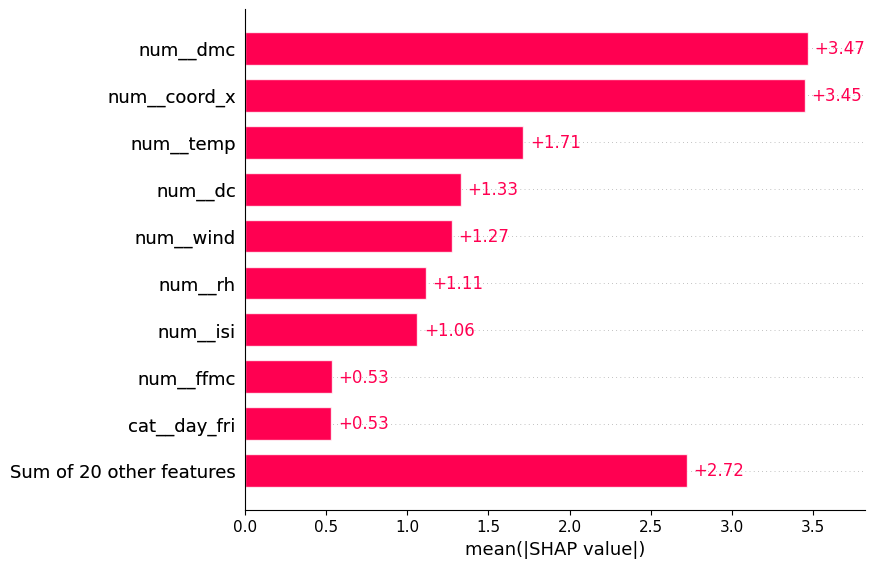

In [122]:
# Plot entire test set
shap.plots.bar(shap_values)


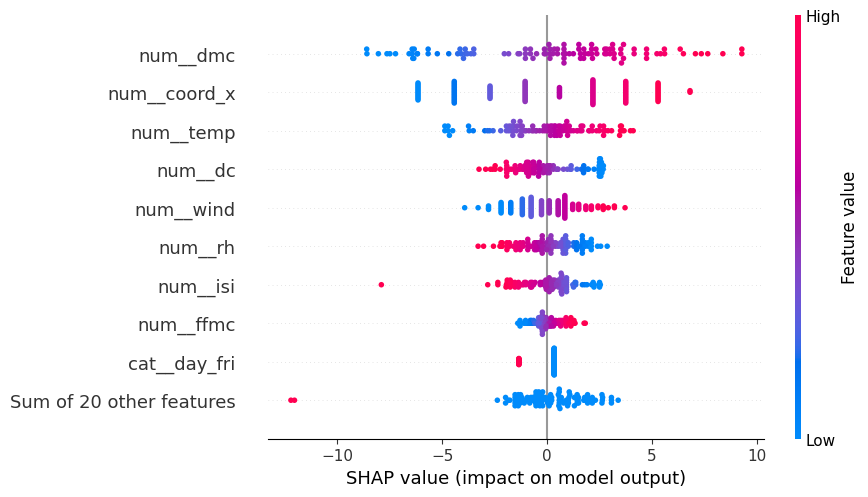

In [123]:
# entire data with beeswarm

shap.plots.beeswarm(shap_values)

*ANSWER:

Local Explanation:
For a single observation in the test set, the SHAP waterfall plot shows that DMC, relative humidity (RH), temperature, and DC are the most influential features driving the model’s prediction. Among these, DMC has the largest impact, indicating it is the dominant contributor for this specific prediction.

Global explanation:
Across the full dataset, global SHAP importance (mean absolute SHAP values) identifies DMC, coord_x, temperature, and DC as the most important features. This ranking is consistent across both the SHAP bar plot and the beeswarm plot. Features such as day-of-week indicators and several meteorological variables show consistently low SHAP values, indicating limited predictive contribution

Feature removal strategy
Low-importance features, particularly weak categorical indicators and variables with consistently small SHAP values, could be candidates for removal to simplify the model. To verify their usefulness, I would retrain the model after removing these features and compare cross-validated performance metrics (e.g., RMSE or MAE). If performance remains stable or improves, this would confirm that these features are not essential.

*

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.